# Experiment 5: Decision Tree and Random Forest – A Comparative Classification Study

## Objective

- To implement a Decision Tree classifier.
- To extend the Decision Tree into a Random Forest ensemble model.
- To study the impact of hyperparameters on overfitting and generalization.
- To select optimal hyperparameters using 5-Fold Cross-Validation.
- To compare single-tree and ensemble-tree models.

## Dataset

The Wisconsin Diagnostic Breast Cancer Dataset is used for this experiment.

- Total samples: 569
- Number of features: 30 numerical attributes
- Target classes: Malignant (M) and Benign (B)

The dataset is obtained from the UCI Machine Learning Repository.

## Importing Required Libraries

Pandas is used to load and manipulate the dataset.

In [23]:
import pandas as pd

## Loading the Dataset

The `wdbc.data` file is loaded using Pandas.

Since the raw dataset does not contain column headers, `header=None` is used while loading the data.

In [24]:
df=pd.read_csv("wdbc.data",header=None)

## Displaying the Dataset

The first five rows of the dataset are displayed to understand its structure and the values present in each column.

In [25]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [26]:
df.shape

(569, 32)

## Assigning Column Names

The WDBC dataset contains an ID column, a diagnosis column, and 30 numerical features.

The 30 features are measurements derived from cell nuclei and are grouped into 10 characteristics, each having three measurements:

- Mean
- Standard Error (SE)
- Worst

Therefore, 30 feature columns are assigned along with the ID and diagnosis columns.

columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df.columns = columns

In [27]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df.columns = columns

In [28]:
df.head()
df.info
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [29]:
df.isnull().sum()



id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [30]:
df.isnull().sum().sum()

np.int64(0)

In [31]:
df.duplicated().sum()

np.int64(0)

## Separating Features and Target

The `id` column is an identifier and is not useful for classification, so it is removed.

The `diagnosis` column is selected as the target variable, while the remaining 30 numerical attributes are used as input features.

In [32]:
X=df.drop(["id","diagnosis"],axis=1)
Y=df["diagnosis"]

print(X.shape)
print(Y.shape)

(569, 30)
(569,)


In [33]:
print(X.head())
print(Y.head())

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave_points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

## Encoding the Target Variable

The target variable contains two categorical class labels: Malignant (M) and Benign (B).

Label encoding is performed to convert these categorical labels into numerical values.

In [34]:
from sklearn.preprocessing import LabelEncoder

model=LabelEncoder()
y=model.fit_transform(Y)
print(y[:10])
print(model.classes_)

[1 1 1 1 1 1 1 1 1 1]
['B' 'M']


## Class Distribution

The target variable is analyzed to determine the distribution of Malignant and Benign samples in the dataset.

Class distribution helps us understand whether the dataset is balanced or imbalanced.

In [35]:
print(df["diagnosis"].value_counts())
print(df["diagnosis"].sum)


diagnosis
B    357
M    212
Name: count, dtype: int64
<bound method Series.sum of 0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: str>


### Class Distribution Plot

A count plot is used to visualize the number of samples belonging to each class.

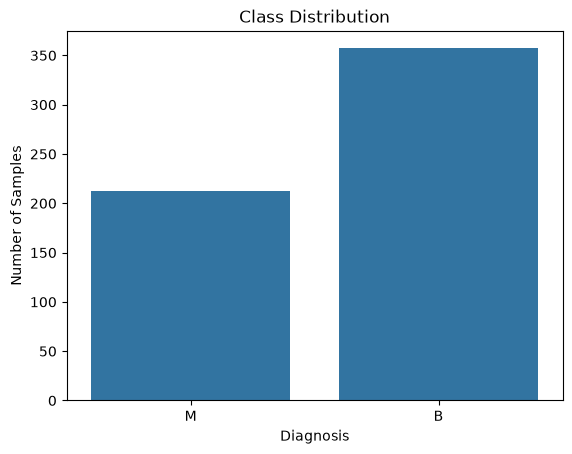

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="diagnosis",data=df)
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()

## Feature Correlation Analysis

Correlation analysis is performed to identify relationships between the numerical features.

A correlation matrix is generated and visualized using a heatmap.

In [37]:
correlation = X.corr()
correlation

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave_points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


### Correlation Heatmap

A heatmap is used to visualize the correlation between the numerical features. Higher absolute correlation values indicate stronger relationships between features.

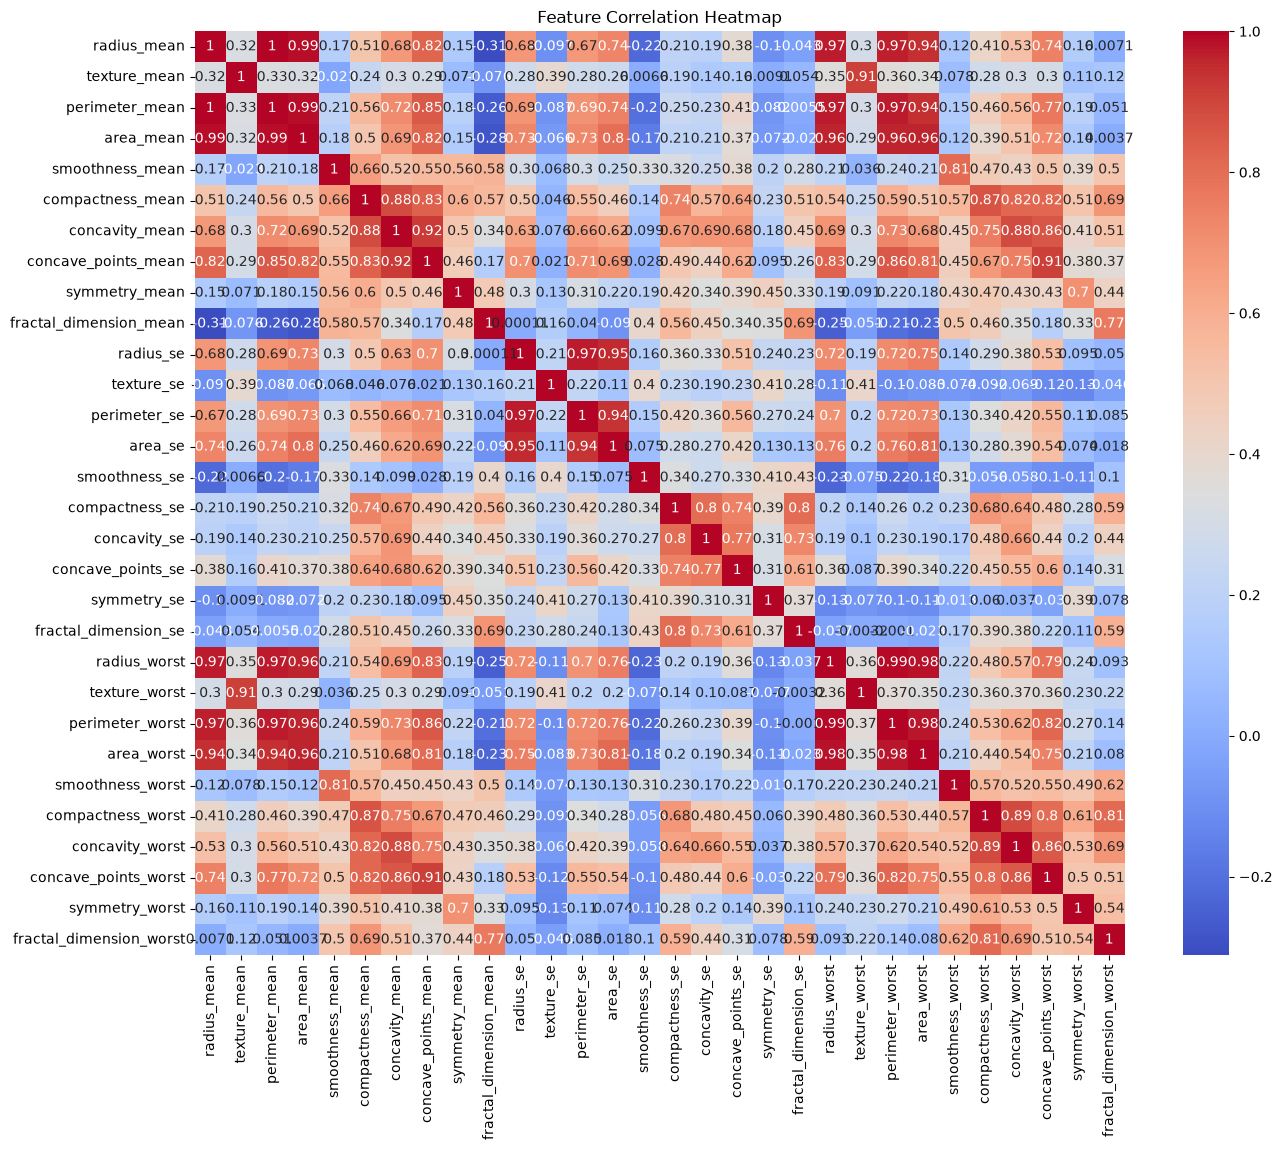

In [38]:
plt.figure(figsize=(15, 12))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

The training set is used to train the machine learning models, while the testing set is used to evaluate their performance on unseen data.

In [39]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", Y_train.shape)
print("Testing target:", Y_test.shape)

Training features: (455, 30)
Testing features: (114, 30)
Training target: (455,)
Testing target: (114,)


## Decision Tree Classifier

A Decision Tree is a supervised learning algorithm that recursively splits the dataset based on feature values to form decision rules. The tree uses impurity measures such as Gini Index or Entropy to determine the quality of a split.

A Decision Tree classifier is trained on the training dataset and then used to predict the classes of the test dataset.

In [40]:
from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,Y_train)

Y_pred_dt=dt_model.predict(X_test)
print(Y_pred_dt[:10])

[0 1 1 0 0 1 1 1 1 0]


## Evaluation of Decision Tree

The performance of the Decision Tree classifier is evaluated using accuracy, precision, recall, F1-score, and confusion matrix.

In [41]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

dt_accuracy=accuracy_score(Y_test,Y_pred_dt)
dt_precision=precision_score(Y_test,Y_pred_dt)
dt_recall=recall_score(Y_test,Y_pred_dt)
dt_f1=f1_score(Y_test,Y_pred_dt)

print("Accuracy :",dt_accuracy)
print("Precision :",dt_precision)
print("Recall :",dt_recall)
print("F1 :",dt_f1)

Accuracy : 0.9473684210526315
Precision : 0.9302325581395349
Recall : 0.9302325581395349
F1 : 0.9302325581395349


In [42]:
cm_dt=confusion_matrix(Y_test,Y_pred_dt)
print("Confusion Matrix :\n",cm_dt)

Confusion Matrix :
 [[68  3]
 [ 3 40]]


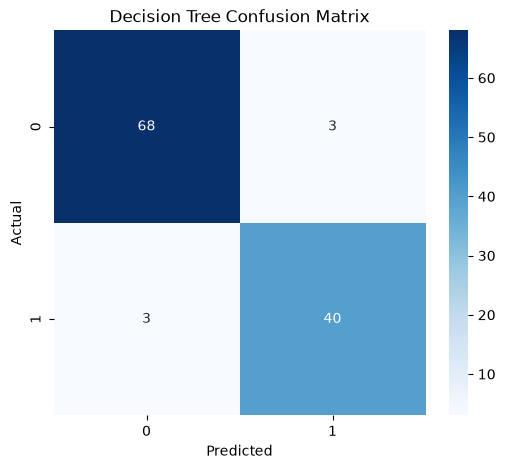

In [43]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Decision Tree Hyperparameter Tuning

Hyperparameters control how a Decision Tree is constructed and how complex the tree can become.

The following hyperparameters are explored:

- **criterion** – determines the impurity measure used for selecting a split.
- **max_depth** – controls the maximum depth of the tree.
- **min_samples_split** – specifies the minimum number of samples required to split an internal node.
- **min_samples_leaf** – specifies the minimum number of samples required in a leaf node.

In [47]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [49]:
from sklearn.model_selection import GridSearchCV

dt_grid_search = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=5,
    scoring="f1"
    
)

dt_grid_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

## Best Decision Tree Hyperparameters

The hyperparameter combination that produces the highest average cross-validation F1-score is selected as the best configuration for the Decision Tree classifier.

In [51]:
print("Best Parameters:")
print(dt_grid_search.best_params_)

print("\nBest Average CV F1-Score:")
print(dt_grid_search.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Average CV F1-Score:
0.92316383251773


In [52]:
best_dt = dt_grid_search.best_estimator_

print(best_dt)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)


## Decision Tree Hyperparameter Evaluation

The Decision Tree hyperparameter combinations are evaluated using 5-Fold Cross-Validation. Both accuracy and F1-score are calculated for each combination. The average cross-validation performance is used to compare the different configurations.

In [53]:
scoring = {
    "accuracy": "accuracy",
    "f1": "f1"
}

dt_grid_search = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
    n_jobs=-1
)

dt_grid_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None chan

In [55]:
dt_results = pd.DataFrame(dt_grid_search.cv_results_)
dt_results[
    [
        "param_criterion",
        "param_max_depth",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].sort_values(
    "mean_test_f1",
    ascending=False
).head(10)

,param_criterion,param_max_depth,mean_test_accuracy,mean_test_f1
48,entropy,3,0.942857,0.923164
46,entropy,3,0.942857,0.923164
45,entropy,3,0.942857,0.923164
49,entropy,3,0.942857,0.923164
68,entropy,7,0.942857,0.920642
56,entropy,5,0.942857,0.920642
59,entropy,5,0.942857,0.920642
65,entropy,7,0.942857,0.920642
77,entropy,10,0.942857,0.920642
74,entropy,10,0.942857,0.920642


## Random Forest Classifier

Random Forest is an ensemble learning technique that combines multiple Decision Trees. Each tree is trained using bootstrapped samples and random feature selection. The final prediction is obtained through majority voting.

Random Forest can reduce the variance of a single Decision Tree and improve generalization.

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)
Y_pred_rf = rf_model.predict(X_test)

print("First 10 predicted values:")
print(Y_pred_rf[:10])

rf_accuracy = accuracy_score(Y_test, Y_pred_rf)
rf_precision = precision_score(Y_test, Y_pred_rf)
rf_recall = recall_score(Y_test, Y_pred_rf)
rf_f1 = f1_score(Y_test, Y_pred_rf)

print("Random Forest Performance")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

First 10 predicted values:
[0 1 1 0 0 1 1 1 1 0]
Random Forest Performance
Accuracy : 0.9649122807017544
Precision: 0.975609756097561
Recall   : 0.9302325581395349
F1-Score : 0.9523809523809523


In [57]:
cm_rf = confusion_matrix(Y_test, Y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[70  1]
 [ 3 40]]


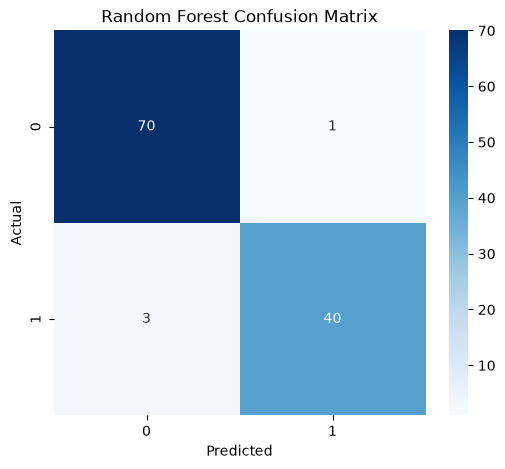

In [58]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Random Forest Hyperparameter Tuning

The Random Forest hyperparameters are explored to study their effect on model performance and generalization.

The following hyperparameters are considered:

- **n_estimators** – number of Decision Trees in the Random Forest.
- **max_depth** – maximum depth allowed for each Decision Tree.
- **max_features** – number or proportion of features considered when finding the best split.
- **bootstrap** – determines whether bootstrap samples are used to train the individual trees.

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

In [60]:
rf_grid_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="f1",
    n_jobs=-1
)

rf_grid_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed fr

In [61]:
refit="f1"
print("Best Random Forest Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Average CV F1-Score:")
print(rf_grid_search.best_score_)

Best Random Forest Parameters:
{'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}

Best Average CV F1-Score:
0.9514879142596534


## Random Forest Hyperparameter Evaluation

The cross-validation results for the different Random Forest hyperparameter combinations are extracted and compared using their average cross-validation accuracy and F1-score.

In [65]:
rf_results = pd.DataFrame(rf_grid_search.cv_results_)
rf_results_table = rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_max_features",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()
rf_results_table.sort_values(
    "mean_test_f1",
    ascending=False
).head(10)

best_rf = rf_grid_search.best_estimator_

print("Best Random Forest:")
print(best_rf)

Best Random Forest:
RandomForestClassifier(bootstrap=False, max_depth=10, n_estimators=50,
                       random_state=42)


## Final Evaluation of Tuned Models

The best Decision Tree and Random Forest models selected through 5-Fold Cross-Validation are evaluated on the unseen test dataset.

The models are compared using accuracy, precision, recall, and F1-score.

In [67]:

Y_pred_best_dt = best_dt.predict(X_test)
Y_pred_best_rf = best_rf.predict(X_test)

dt_accuracy = accuracy_score(Y_test, Y_pred_best_dt)
dt_precision = precision_score(Y_test, Y_pred_best_dt)
dt_recall = recall_score(Y_test, Y_pred_best_dt)
dt_f1 = f1_score(Y_test, Y_pred_best_dt)

rf_accuracy = accuracy_score(Y_test, Y_pred_best_rf)
rf_precision = precision_score(Y_test, Y_pred_best_rf)
rf_recall = recall_score(Y_test, Y_pred_best_rf)
rf_f1 = f1_score(Y_test, Y_pred_best_rf)


print("Tuned Decision Tree")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)

print("\nTuned Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

Tuned Decision Tree
Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9069767441860465
F1-Score : 0.9512195121951219

Tuned Random Forest
Accuracy : 0.956140350877193
Precision: 0.9523809523809523
Recall   : 0.9302325581395349
F1-Score : 0.9411764705882353


In [68]:
cm_best_dt = confusion_matrix(Y_test, Y_pred_best_dt)
cm_best_rf = confusion_matrix(Y_test, Y_pred_best_rf)

print("Tuned Decision Tree Confusion Matrix:")
print(cm_best_dt)

print("\nTuned Random Forest Confusion Matrix:")
print(cm_best_rf)

Tuned Decision Tree Confusion Matrix:
[[71  0]
 [ 4 39]]

Tuned Random Forest Confusion Matrix:
[[69  2]
 [ 3 40]]


## ROC Curve and AUC

The Receiver Operating Characteristic (ROC) curve is used to evaluate the classification performance of the tuned Decision Tree and Random Forest models at different classification thresholds.

The Area Under the Curve (AUC) summarizes the ROC curve into a single value. A higher AUC indicates better ability to distinguish between the two classes.

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score

dt_prob = best_dt.predict_proba(X_test)[:, 1]
rf_prob = best_rf.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(Y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(Y_test, rf_prob)

auc_dt = roc_auc_score(Y_test, dt_prob)
auc_rf = roc_auc_score(Y_test, rf_prob)

print("Decision Tree AUC :", auc_dt)
print("Random Forest AUC :", auc_rf)

Decision Tree AUC : 0.9715034392400917
Random Forest AUC : 0.9931215198165739


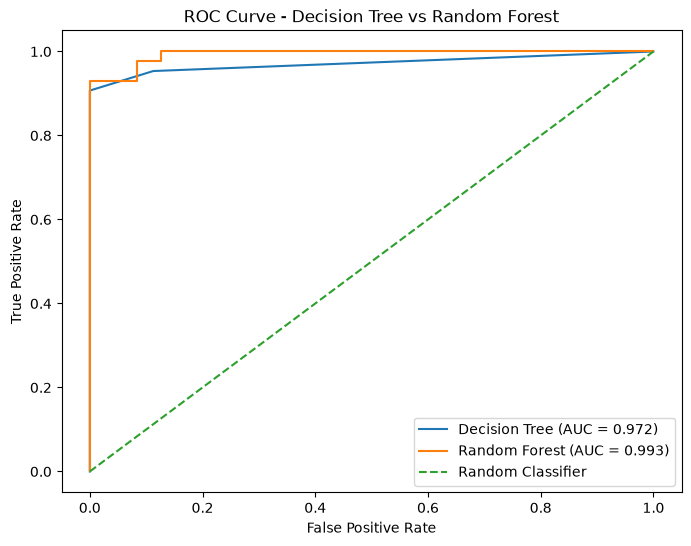

In [70]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {auc_dt:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree vs Random Forest")
plt.legend()
plt.show()

## 5-Fold Cross-Validation Performance Comparison

The tuned Decision Tree and Random Forest models are compared using 5-Fold Cross-Validation. The accuracy obtained in each fold and the average accuracy across the five folds are recorded.

In [72]:
from sklearn.model_selection import cross_val_score

dt_fold_scores = cross_val_score(
    best_dt,
    X_train,
    Y_train,
    cv=5,
    scoring="accuracy"
)

rf_fold_scores = cross_val_score(
    best_rf,
    X_train,
    Y_train,
    cv=5,
    scoring="accuracy"
)
print("Decision Tree Fold Accuracies:")
print(dt_fold_scores)

print("\nRandom Forest Fold Accuracies:")
print(rf_fold_scores)

Decision Tree Fold Accuracies:
[0.97802198 0.91208791 0.94505495 0.94505495 0.93406593]

Random Forest Fold Accuracies:
[0.97802198 0.95604396 0.96703297 0.97802198 0.94505495]


In [75]:
print("Decision Tree Average Accuracy:",dt_fold_scores.mean())
print("Random Forest Average Accuracy:",rf_fold_scores.mean())

Decision Tree Average Accuracy: 0.9428571428571428
Random Forest Average Accuracy: 0.9648351648351647


In [76]:
cv_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_fold_scores[0], rf_fold_scores[0]],
    "Fold 2": [dt_fold_scores[1], rf_fold_scores[1]],
    "Fold 3": [dt_fold_scores[2], rf_fold_scores[2]],
    "Fold 4": [dt_fold_scores[3], rf_fold_scores[3]],
    "Fold 5": [dt_fold_scores[4], rf_fold_scores[4]],
    "Average": [
        dt_fold_scores.mean(),
        rf_fold_scores.mean()
    ]
})

cv_comparison

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.978022,0.912088,0.945055,0.945055,0.934066,0.942857
1,Random Forest,0.978022,0.956044,0.967033,0.978022,0.945055,0.964835


## 5-Fold Cross-Validation Accuracy Comparison

The tuned Decision Tree and Random Forest models are evaluated using 5-Fold Cross-Validation. The accuracy obtained in each fold and the average accuracy across all five folds are compared.

In [77]:
from sklearn.model_selection import cross_val_score


dt_fold_scores = cross_val_score(
    best_dt,
    X_train,
    Y_train,
    cv=5,
    scoring="accuracy"
)


rf_fold_scores = cross_val_score(
    best_rf,
    X_train,
    Y_train,
    cv=5,
    scoring="accuracy"
)


print("Decision Tree Fold Accuracies:")
print(dt_fold_scores)

print("\nRandom Forest Fold Accuracies:")
print(rf_fold_scores)

# Display average accuracy
print("\nDecision Tree Average Accuracy:",dt_fold_scores.mean())

print("Random Forest Average Accuracy:",rf_fold_scores.mean())

Decision Tree Fold Accuracies:
[0.97802198 0.91208791 0.94505495 0.94505495 0.93406593]

Random Forest Fold Accuracies:
[0.97802198 0.95604396 0.96703297 0.97802198 0.94505495]

Decision Tree Average Accuracy: 0.9428571428571428
Random Forest Average Accuracy: 0.9648351648351647


In [78]:
import pandas as pd

cv_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_fold_scores[0], rf_fold_scores[0]],
    "Fold 2": [dt_fold_scores[1], rf_fold_scores[1]],
    "Fold 3": [dt_fold_scores[2], rf_fold_scores[2]],
    "Fold 4": [dt_fold_scores[3], rf_fold_scores[3]],
    "Fold 5": [dt_fold_scores[4], rf_fold_scores[4]],
    "Average": [
        dt_fold_scores.mean(),
        rf_fold_scores.mean()
    ]
})

cv_comparison

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.978022,0.912088,0.945055,0.945055,0.934066,0.942857
1,Random Forest,0.978022,0.956044,0.967033,0.978022,0.945055,0.964835
